Sentiment Analysis (API) comparison Tests

1. In this Notebook different sentiment analytics related API's will be tested, firstly testing with the basic GDELT (Quantitative) vs NewsAPI (Qualitative) on the filtered.
2. I have used companies house dataset to assess news coverage feasibility.

3. News API Feasibility Test; 
   Main goal here is to tell whether companies in our filtered   dataset actually appear in the news coverage, and compare 2 APIs
4. I took a stratified sample of approx 30 companies across sectors  and tiers, searching each company in both APIs and compare coverage rates.

In [8]:
#Loading the filtered dataset (viktor) and taking an approx sample
import pandas as pd
import requests
import time
import json
from datetime import datetime, timedelta

#Loading the filtered dataset
FILTERED_CSV_PATH = "../filtered_bb_sme_sectors.csv"
df = pd.read_csv(FILTERED_CSV_PATH)
 
print(f"Total companies in filtered dataset: {len(df):,}")
print(f"Sectors: {df['sector'].value_counts().to_dict()}")

C:\Users\visha\AppData\Local\Temp\ipykernel_29620\3912590984.py:10: DtypeWarning: Columns (43,44,45,46,47,48,49,50,51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILTERED_CSV_PATH)


Total companies in filtered dataset: 1,372,321
Sectors: {'Technology, legal & professional': 837066, 'Fast growth & emerging': 320670, 'Manufacturing': 214585}


In [9]:
#Since the csv is quite big, before hitting any API testing's.
#I will first understand what segments exist and how many companies in each?

print("Segment breakdown:")
print(df["segment"].value_counts())
print()

# What sectors exist?
print("Sector breakdown:")
print(df["sector"].value_counts())
print()

# Cross-tabulation: segment by sector
print("Segment x Sector:")
print(pd.crosstab(df["segment"], df["sector"], margins=True))
print()

# Company status - are all companies active?
print("Company status:")
print(df["CompanyStatus"].value_counts())
print()

# Account category
print("Account category:")
print(df["Accounts.AccountCategory"].value_counts())

Segment breakdown:
segment
Micro         501253
Small         367790
No Filings    307818
Dormant       155645
Large          28940
Subsidiary      8888
Medium          1959
Unknown           25
Name: count, dtype: int64

Sector breakdown:
sector
Technology, legal & professional    837066
Fast growth & emerging              320670
Manufacturing                       214585
Name: count, dtype: int64

Segment x Sector:
sector      Fast growth & emerging  Manufacturing  \
segment                                             
Dormant                      33039          24137   
Large                         4469           8866   
Medium                         237           1181   
Micro                       118740          63236   
No Filings                   91862          43558   
Small                        70804          72316   
Subsidiary                    1519           1286   
Unknown                          0              4   
All                         320670         214584

Now since all 1.37M companies are active (status filtering is already done), a third of them are either dormant (155K) or have no filings (308k). 

1. From what I've understood is these companies may not appear in any news coverage, so for now will exclude them from API test.
2. Now the rest of the breakdown would be: Micro (501k) BB tier,
   Small (368k) cover BB and SME.
3. Medium is (2k) is upper SME. And large (29k) is beyond the SME sweet spot but has potential.
4. Subsidiary (9k) is a part of bigger groups and probably wont have their own standalone news cover.

   for this test, will filter to Micro, Small, and Medium only.
   

In [10]:
#Filtering to relevant segments for news testing
relevant_segments = ["Micro", "Small", "Medium"]
df_testing = df[df["segment"].isin(relevant_segments)].copy()

print(f"Companies for news testing: {len(df_testing):,}")
print(f"\nSegment breakdown:")
print(df_testing["segment"].value_counts())
print(f"\nSector breakdown:")
print(df_testing["sector"].value_counts())

Companies for news testing: 871,002

Segment breakdown:
segment
Micro     501253
Small     367790
Medium      1959
Name: count, dtype: int64

Sector breakdown:
sector
Technology, legal & professional    544488
Fast growth & emerging              189781
Manufacturing                       136733
Name: count, dtype: int64


---
Now i will take a sample from the above subset, to get a mix of all segments and sectors. 

Which is important cus we want to see whether bigger companies (small/med) get more news coverage than tiny ones (micro).

Since we a grouping by two things instead of one, sector AND segment. which is 3 sectors times 3 segments (Mic, Small, Med) : which is 9 combinations (which i reckon would'nt have interesting results)

Thus i'll take approx of 8 per combination thats 72 companies i cover, please note your API will take longer to run but will give better coverage.

In [11]:
#Here i Take a stratified sample: approx ~8 per sector, with mixing tiers

sample_frames = []
for (sector, segment), group in df_testing.groupby(["sector", "segment"]):
    n = min(8, len(group))
    sample_frames.append(group.sample(n, random_state=42))

sample = pd.concat(sample_frames).reset_index(drop=True)

print(f"Sample size: {len(sample)} companies")
print(f"\nSample breakdown by sector:")
print(sample["sector"].value_counts())
print(f"\nSample breakdown by segment:")
print(sample["segment"].value_counts())
print(f"\nCross-tabulation:")
print(pd.crosstab(sample["segment"], sample["sector"], margins=True))
print(f"\nSample companies:")
print(sample[["CompanyName", "sector", "segment"]].to_string(index=False))

Sample size: 72 companies

Sample breakdown by sector:
sector
Fast growth & emerging              24
Manufacturing                       24
Technology, legal & professional    24
Name: count, dtype: int64

Sample breakdown by segment:
segment
Medium    24
Micro     24
Small     24
Name: count, dtype: int64

Cross-tabulation:
sector   Fast growth & emerging  Manufacturing  \
segment                                          
Medium                        8              8   
Micro                         8              8   
Small                         8              8   
All                          24             24   

sector   Technology, legal & professional  All  
segment                                         
Medium                                  8   24  
Micro                                   8   24  
Small                                   8   24  
All                                    24   72  

Sample companies:
                          CompanyName                      

---
Now I will run the GDELT DOC API (search function)
1. Some Info about GDELT DOC API :
   - Its a massive project wich scans tens and thousands of news websites around the world, i.e BBC, Guardian, Financial Times etc.
   - Runs 24/7 and picks up new articles every 15 minutes
   - Does 3 things automatically which it finds an article:
   - Reads full text
   - Who and what is article related to (Comp, ppl, loc)
   - Calculates a tone score (positive / negative)
2. Doc API is just the search interface to the database where all of this gets stored in.

*No API key is needed

In [25]:
#Testing GDELT DOC API - search function

GDELT_BASE_URL = "https://api.gdeltproject.org/api/v2/doc/doc" 

def clean_company_name(raw_name: str) -> str:
    """Remove common suffixes for better search results."""
    name = raw_name.strip().upper()
    for suffix in [" LIMITED", " LTD", " PLC", " LLP", " INC", " CORP", " GROUP", " HOLDINGS", " CIC"]:
        if name.endswith(suffix):
            name = name[:-len(suffix)].strip()
    return name

def search_gdelt(company_name: str) -> list:
    """Search GDELT for articles mentioning a company in the last 6 months."""
    clean_name = clean_company_name(company_name)
    if len(clean_name) < 3:
        return []
    params = {
        "query": f'"{clean_name}" sourcelang:english',
        "mode": "artlist",
        "maxrecords": "50",
        "format": "json",
        "timespan": "6m",
        "sort": "datedesc",
    }
    try:
        response = requests.get(GDELT_BASE_URL, params=params, timeout=20)
        if response.status_code == 200:
            data = response.json()
            return data.get("articles", [])
        return []
    except Exception:
        return []

Status: 429
Response: Please limit requests to one every 5 seconds or contact kalev.leetaru5@gmail.com for larger queries.




CODE COMMENTED FOR TIME BEING, SANITY CHECK IN PROGRESS
#Now running the search, using the API on the sample we created.

print("SEARCHING GDELT DOC API")

gdelt_results = []

for idx, row in sample.iterrows():
    name = row["CompanyName"]
    print(f"[{len(gdelt_results)+1}/{len(sample)}] {name}...", end=" ")

    articles = search_gdelt(name)
    article_count = len(articles)

    tones = [a.get("tone", 0) for a in articles if "tone" in a]
    avg_tone = round(sum(tones) / len(tones), 2) if tones else None

    gdelt_results.append({
        "CompanyName": name,
        "sector": row["sector"],
        "segment": row["segment"],
        "gdelt_articles": article_count,
        "gdelt_has_coverage": article_count > 0,
        "gdelt_avg_tone": avg_tone,
    })

    print(f"Found {article_count} articles")
    time.sleep(1.5)

gdelt_df = pd.DataFrame(gdelt_results)


print(f"Companies searched: {len(gdelt_df)}")
print(f"With coverage: {gdelt_df['gdelt_has_coverage'].sum()}")
print(f"Coverage rate: {gdelt_df['gdelt_has_coverage'].mean():.1%}")
print(f"\nCoverage by sector:")
print(gdelt_df.groupby("sector")["gdelt_has_coverage"].mean())
print(f"\nCoverage by segment:")
print(gdelt_df.groupby("segment")["gdelt_has_coverage"].mean())

---
Before taking the above results at face value.
Ill run a sanity check with the companies I know will have news coverage.

- If it does return results, the API should be working fine, and the zero coverage for the 72 companies would be genuine.

In [13]:
# Test with proper rate limiting
import time

response = requests.get(
    "https://api.gdeltproject.org/api/v2/doc/doc",
    params={
        "query": '"Tesco" sourcelang:english',
        "mode": "artlist",
        "maxrecords": "10",
        "format": "json",
        "timespan": "6m",
    },
    timeout=20
)

print(f"Status: {response.status_code}")
print(f"Response: {response.text[:500]}")

Status: 429
Response: Please limit requests to one every 5 seconds or contact kalev.leetaru5@gmail.com for larger queries.




---
NEWS API test, on the same sample.
*Note, Use your key when running this block

you can register for one from: https://newsapi.org/register 
- NEWS API has a clear rate limit of 100 req per day so this wont be an issue as long as we dont exceed

In [14]:
# NewsAPI - search function

NEWS_API_KEY = "82065702ced04dfeaa203763b44789c2"  # replace this, with ur key
NEWSAPI_URL = "https://newsapi.org/v2/everything"

def search_newsapi(company_name: str) -> list:
    clean_name = clean_company_name(company_name)
    if len(clean_name) < 3:
        return []
    date_from = (datetime.now() - timedelta(days=30)).strftime("%Y-%m-%d")
    params = {
        "q": f'"{clean_name}"',
        "from": date_from,
        "language": "en",
        "sortBy": "relevancy",
        "pageSize": 50,
        "apiKey": NEWS_API_KEY,
    }
    try:
        response = requests.get(NEWSAPI_URL, params=params, timeout=20)
        if response.status_code == 200:
            data = response.json()
            return data.get("articles", [])
        return []
    except Exception:
        return []

In [15]:
#Now running the sample on NEWS API

newsapi_results = []

for idx, row in sample.iterrows():
    name = row["CompanyName"]
    print(f"[{len(newsapi_results)+1}/{len(sample)}] {name}...", end=" ")

    articles = search_newsapi(name)
    article_count = len(articles)
    sources = list(set(a.get("source", {}).get("name", "") for a in articles))

    newsapi_results.append({
        "CompanyName": name,
        "sector": row["sector"],
        "segment": row["segment"],
        "newsapi_articles": article_count,
        "newsapi_has_coverage": article_count > 0,
        "newsapi_sources": ", ".join(sources[:5]) if sources else None,
    })

    print(f"Found {article_count} articles")
    time.sleep(1)

newsapi_df = pd.DataFrame(newsapi_results)

[1/72] INTEQ CONTROLS LIMITED... Found 0 articles
[2/72] AVEVA FINANCE LIMITED... Found 0 articles
[3/72] TOTAL RECRUIT LTD... Found 0 articles
[4/72] LANTRONIX UK LIMITED... Found 0 articles
[5/72] ADVANIA UK (SERVIUM) LIMITED... Found 0 articles
[6/72] RADIO COMPUTING SERVICES (UK) LIMITED... Found 0 articles
[7/72] ALCHEMY TECHNOLOGY SERVICES LIMITED... Found 0 articles
[8/72] VELA SOFTWARE LIMITED... Found 5 articles
[9/72] AUTHORITY DIGITAL LTD... Found 5 articles
[10/72] COASTER LIMITED... Found 47 articles
[11/72] CODEMONKEY LTD... Found 0 articles
[12/72] NELLURI TECH LIMITED... Found 0 articles
[13/72] XEROCRYPT LTD... Found 0 articles
[14/72] TH COMMUNICATIONS LIMITED... Found 0 articles
[15/72] J.C. COMPUTER SERVICES (UK) LIMITED... Found 0 articles
[16/72] AMSA SOLUTIONS LTD... Found 0 articles
[17/72] MONTEDIN LTD... Found 0 articles
[18/72] MALUI CONSULTING LTD... Found 0 articles
[19/72] UX SEQUENCE LTD... Found 0 articles
[20/72] NETOVA TECHNOLOGY LTD... Found 0 article

In [16]:
#News APi results
print(f"Companies searched: {len(newsapi_df)}")
print(f"With coverage: {newsapi_df['newsapi_has_coverage'].sum()}")
print(f"Coverage rate: {newsapi_df['newsapi_has_coverage'].mean():.1%}")
print(f"\nCoverage by sector:")
print(newsapi_df.groupby("sector")["newsapi_has_coverage"].mean())
print(f"\nCoverage by segment:")
print(newsapi_df.groupby("segment")["newsapi_has_coverage"].mean())

Companies searched: 72
With coverage: 5
Coverage rate: 6.9%

Coverage by sector:
sector
Fast growth & emerging              0.125000
Manufacturing                       0.041667
Technology, legal & professional    0.041667
Name: newsapi_has_coverage, dtype: float64

Coverage by segment:
segment
Medium    0.083333
Micro     0.125000
Small     0.000000
Name: newsapi_has_coverage, dtype: float64


In [17]:
# Which companies had coverage?
covered = newsapi_df[newsapi_df["newsapi_has_coverage"]]
print("Companies with NewsAPI coverage:")
print(covered[["CompanyName", "sector", "segment", "newsapi_articles", "newsapi_sources"]].to_string(index=False))

Companies with NewsAPI coverage:
          CompanyName                           sector segment  newsapi_articles                                                                 newsapi_sources
VELA SOFTWARE LIMITED           Fast growth & emerging  Medium                 5                     Financial Post, PRNewswire, Associated Press, GlobeNewswire
AUTHORITY DIGITAL LTD           Fast growth & emerging   Micro                 5                                 CryptoSlate, PRNewswire, Decrypt, Dailymail.com
      COASTER LIMITED           Fast growth & emerging   Micro                47               Gizmodo.com, /FILM, TechRadar, disneyfoodblog.com, Boredpanda.com
       RICH MAKES LTD                    Manufacturing   Micro                 3                                      Smashingapps.com, PRNewswire, Mother Jones
     BARONESS LIMITED Technology, legal & professional  Medium                37 Dpa-international.com, BBC News, The Daily Caller, Breitbart News, Punknews.org


The above helps in understanding (deeper) which companies actually had proper coverage, as we need to check whether those exact 5 hits are genuinely about the companies

OR

Just false positives from common names matching unrelated articulates. if 3 out of 5 are false positives, your real coverage rate drops from 6.9% to under 3%

---

Results / Tests conducted so far:

Test sample: 72 companies (stratified by sector and segment)
Segments tested: Micro, Small, Medium
Segments excluded: Dormant, No Filings, Large, Subsidiary

API TESTED: NewsAPI (free tier, last 30 days)
- Coverage rate: 6.9% (5 out of 72 companies)
- Fast growth & emerging: 12.5% coverage
- Manufacturing: 4.2% coverage  
- Technology, legal & professional: 4.2% coverage

what i foundout was :

SMEs and micro companies have extremely low news coverage.
Only ~7% of tested companies appeared in any news source.
This confirms the finding from earlier team experiments.

This is obviously with the APIs we have already tested, now i will test further up with larger MNC's and organisations whose turnover is over a Million.

---

The Guardian Open Platform API: https://open-platform.theguardian.com/access/

Since our whole project is on a UK specific scale, and not a global operation. the apis i used previously i.e GDELT and NewsAPI

- Are Global which means the UK SME coverage will be diluted.
- The Guardian will be more UK specific coverage hence i think is the best option moving forward
- Its a free API, but fill the form correctly to get the API KEY
- Covers proper news sources in the UK

In [18]:
#The Guardian Open Platform test
import requests
import time
import pandas as pd

GUARDIAN_API_KEY = "dccdc4dc-6665-4a0b-94aa-778f1503fd1c"  # replace with your key here
GUARDIAN_URL = "https://content.guardianapis.com/search"

def clean_company_name(raw_name: str) -> str:
    """Remove common suffixes for better search results."""
    name = raw_name.strip().upper()
    for suffix in [" LIMITED", " LTD", " PLC", " LLP", " INC", " CORP", " GROUP", " HOLDINGS", " CIC"]:
        if name.endswith(suffix):
            name = name[:-len(suffix)].strip()
    return name

def search_guardian(company_name: str, api_key: str) -> list:
    """Search The Guardian for articles mentioning a company in the last 6 months."""
    clean_name = clean_company_name(company_name)
    if len(clean_name) < 3:
        return []
    params = {
        "q": f'"{clean_name}"',
        "section": "business|money|technology|uk-news",
        "from-date": "2025-01-01",
        "page-size": 50,
        "show-fields": "headline,trailText,wordcount",
        "api-key": api_key,
    }
    try:
        response = requests.get(GUARDIAN_URL, params=params, timeout=20)
        if response.status_code == 200:
            data = response.json()
            return data.get("response", {}).get("results", [])
        print(f" [Error: {response.status_code}]", end="")
        return []
    except Exception:
        return []

In [19]:
#Running the above results on the sample we created earlier

guardian_results = []

for idx, row in sample.iterrows():
    name = row["CompanyName"]
    print(f"[{len(guardian_results)+1}/{len(sample)}] {name}...", end=" ")

    articles = search_guardian(name, GUARDIAN_API_KEY)
    article_count = len(articles)

    headlines = [a.get("fields", {}).get("headline", "") for a in articles[:3]]

    guardian_results.append({
        "CompanyName": name,
        "sector": row["sector"],
        "segment": row["segment"],
        "guardian_articles": article_count,
        "guardian_has_coverage": article_count > 0,
        "guardian_sample_headlines": " | ".join(headlines) if headlines else None,
    })

    print(f"Found {article_count} articles")
    time.sleep(1)

guardian_df = pd.DataFrame(guardian_results)

# Save immediately so you don't lose results
guardian_df.to_csv("guardian_results.csv", index=False)

[1/72] INTEQ CONTROLS LIMITED... Found 0 articles
[2/72] AVEVA FINANCE LIMITED... Found 0 articles
[3/72] TOTAL RECRUIT LTD... Found 0 articles
[4/72] LANTRONIX UK LIMITED... Found 0 articles
[5/72] ADVANIA UK (SERVIUM) LIMITED...  [Error: 400]Found 0 articles
[6/72] RADIO COMPUTING SERVICES (UK) LIMITED...  [Error: 400]Found 0 articles
[7/72] ALCHEMY TECHNOLOGY SERVICES LIMITED... Found 0 articles
[8/72] VELA SOFTWARE LIMITED... Found 0 articles
[9/72] AUTHORITY DIGITAL LTD... Found 0 articles
[10/72] COASTER LIMITED... Found 8 articles
[11/72] CODEMONKEY LTD... Found 0 articles
[12/72] NELLURI TECH LIMITED... Found 0 articles
[13/72] XEROCRYPT LTD... Found 0 articles
[14/72] TH COMMUNICATIONS LIMITED... Found 0 articles
[15/72] J.C. COMPUTER SERVICES (UK) LIMITED...  [Error: 400]Found 0 articles
[16/72] AMSA SOLUTIONS LTD... Found 0 articles
[17/72] MONTEDIN LTD... Found 0 articles
[18/72] MALUI CONSULTING LTD... Found 0 articles
[19/72] UX SEQUENCE LTD... Found 0 articles
[20/72] NE

In [20]:
#The Guardian Open Platform Results
print(f"Companies searched: {len(guardian_df)}")
print(f"With coverage: {guardian_df['guardian_has_coverage'].sum()}")
print(f"Coverage rate: {guardian_df['guardian_has_coverage'].mean():.1%}")
print(f"\nCoverage by sector:")
print(guardian_df.groupby("sector")["guardian_has_coverage"].mean())
print(f"\nCoverage by segment:")
print(guardian_df.groupby("segment")["guardian_has_coverage"].mean())

Companies searched: 72
With coverage: 2
Coverage rate: 2.8%

Coverage by sector:
sector
Fast growth & emerging              0.041667
Manufacturing                       0.000000
Technology, legal & professional    0.041667
Name: guardian_has_coverage, dtype: float64

Coverage by segment:
segment
Medium    0.041667
Micro     0.041667
Small     0.000000
Name: guardian_has_coverage, dtype: float64


---
Here, will check which 2 companies had a genuine coverage and not just false positives

The results are ever more lower than NEWSAPI which suggests that SME's in UK barely exist in news coverage

In [21]:
covered_guardian = guardian_df[guardian_df["guardian_has_coverage"]]
print("Guardian coverage:")
print(covered_guardian[["CompanyName", "sector", "segment", "guardian_articles", "guardian_sample_headlines"]].to_string(index=False))

Guardian coverage:
     CompanyName                           sector segment  guardian_articles                                                                                                                                                                                                                                                                                        guardian_sample_headlines
 COASTER LIMITED           Fast growth & emerging   Micro                  8 Luxury watches, iPads and a Jaguar: what Peter Murrell bought with embezzled funds | Motorhome bought by Murrell with stolen SNP money was driven only 4 miles, court told | Middle East war creating ‘largest supply disruption in the history of oil markets’, as Brent crude hits $100 again – as it happened
BARONESS LIMITED Technology, legal & professional  Medium                 16                                                                                 Michelle Mone says she has ‘no wish’ to remain a Conservativ

---
Now below i will test the GNews API, which directly pulls from Google News Aggregation and gives about 100 requests per day.

You can generate for a key here : https://gnews.io/ 

Gnews API pulls directly from Google News and indexes articles from thousands of publishers globally.

So Sonice UK based SMEs are  unlikely to appear in major outlets such as BBC or Reuters, there is a chance they might show up in these smaller, niche sources which google indexes

I specifically have filtered for the UK-based English language results, u will get 100 requests per day with upto 10 articles per search.


In [22]:
#Testing the GnewsAPI

import requests
import time
import pandas as pd

GNEWS_API_KEY = "04a589b614ff9e9e3d6b1a44431ed6e8" #Enter your API key here
GNEWS_URL = "https://gnews.io/api/v4/search"

def search_gnews(company_name: str, api_key: str) -> list:
    """Search GNews for articles mentioning a company."""
    clean_name = clean_company_name(company_name)
    if len(clean_name) < 3:
        return []
    params = {
        "q": f'"{clean_name}"',
        "lang": "en",
        "country": "gb",
        "max": 10,
        "apikey": api_key,
    }
    try:
        response = requests.get(GNEWS_URL, params=params, timeout=20)
        if response.status_code == 200:
            data = response.json()
            return data.get("articles", [])
        print(f" [Error: {response.status_code}]", end="")
        return []
    except Exception:
        return []

In [23]:
#Searching for articles with GNEWSAPI

gnews_results = []

for idx, row in sample.iterrows():
    name = row["CompanyName"]
    print(f"[{len(gnews_results)+1}/{len(sample)}] {name}...", end=" ")

    articles = search_gnews(name, GNEWS_API_KEY)
    article_count = len(articles)
    sources = [a.get("source", {}).get("name", "") for a in articles]

    gnews_results.append({
        "CompanyName": name,
        "sector": row["sector"],
        "segment": row["segment"],
        "gnews_articles": article_count,
        "gnews_has_coverage": article_count > 0,
        "gnews_sources": ", ".join(set(sources[:5])) if sources else None,
    })

    print(f"Found {article_count} articles")
    time.sleep(1)

gnews_df = pd.DataFrame(gnews_results)
gnews_df.to_csv("gnews_results.csv", index=False)



[1/72] INTEQ CONTROLS LIMITED... Found 0 articles
[2/72] AVEVA FINANCE LIMITED... Found 0 articles
[3/72] TOTAL RECRUIT LTD... Found 0 articles
[4/72] LANTRONIX UK LIMITED... Found 0 articles
[5/72] ADVANIA UK (SERVIUM) LIMITED... Found 0 articles
[6/72] RADIO COMPUTING SERVICES (UK) LIMITED... Found 0 articles
[7/72] ALCHEMY TECHNOLOGY SERVICES LIMITED... Found 0 articles
[8/72] VELA SOFTWARE LIMITED... Found 1 articles
[9/72] AUTHORITY DIGITAL LTD... Found 0 articles
[10/72] COASTER LIMITED... Found 10 articles
[11/72] CODEMONKEY LTD... Found 0 articles
[12/72] NELLURI TECH LIMITED... Found 0 articles
[13/72] XEROCRYPT LTD... Found 0 articles
[14/72] TH COMMUNICATIONS LIMITED... Found 0 articles
[15/72] J.C. COMPUTER SERVICES (UK) LIMITED... Found 0 articles
[16/72] AMSA SOLUTIONS LTD... Found 0 articles
[17/72] MONTEDIN LTD... Found 0 articles
[18/72] MALUI CONSULTING LTD... Found 0 articles
[19/72] UX SEQUENCE LTD... Found 0 articles
[20/72] NETOVA TECHNOLOGY LTD... Found 0 article

In [24]:
#Print results
print(f"Companies searched: {len(gnews_df)}")
print(f"With coverage: {gnews_df['gnews_has_coverage'].sum()}")
print(f"Coverage rate: {gnews_df['gnews_has_coverage'].mean():.1%}")
print(f"\nCoverage by sector:")
print(gnews_df.groupby("sector")["gnews_has_coverage"].mean())
print(f"\nCoverage by segment:")
print(gnews_df.groupby("segment")["gnews_has_coverage"].mean())

Companies searched: 72
With coverage: 3
Coverage rate: 4.2%

Coverage by sector:
sector
Fast growth & emerging              0.083333
Manufacturing                       0.000000
Technology, legal & professional    0.041667
Name: gnews_has_coverage, dtype: float64

Coverage by segment:
segment
Medium    0.083333
Micro     0.041667
Small     0.000000
Name: gnews_has_coverage, dtype: float64


---
MIDPOINT OUTCOME CHECK
- APIs tested so far :
- NewsAPI ~ Free tier covers last 30 days only with 100 requests per day. Coverage: 5 out of 72 companies (6.9%)
- The Guardian Open Platform ~ More UK specific, full article text. Free with 12 requests P/S. Coverage: 2 out of 72 (2.8%)
- GNews API ~ Free tier give 100 requests per day. *there is no built in sentiment. Coverage: 3 out of 72 (4.2%)
- GDELT DOC API ~ Free, No API key is needed here. but remember to keep like Min 5 secs b/w requests. [ my email is banned due to rapid requests :) ]

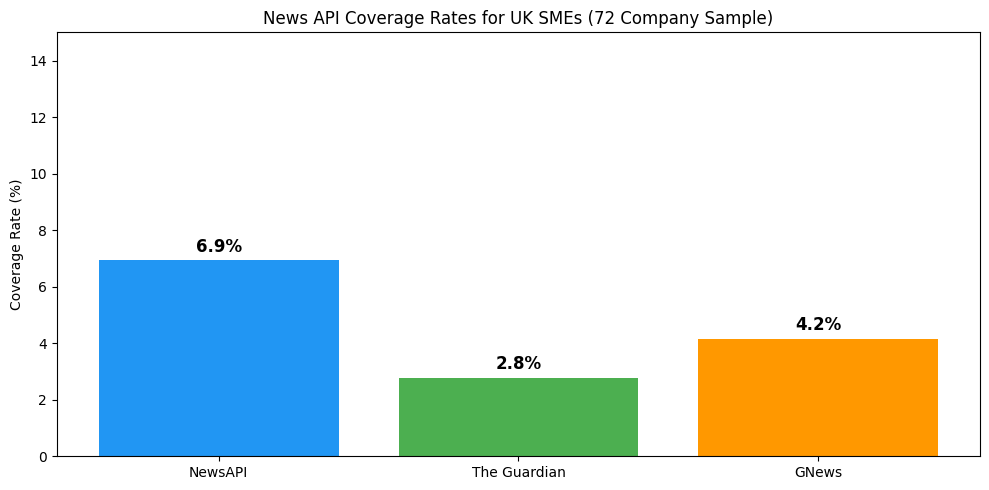

In [37]:
import matplotlib.pyplot as plt

# Overall coverage comparison
apis = ["NewsAPI", "The Guardian", "GNews"]
rates = [
    newsapi_df["newsapi_has_coverage"].mean() * 100,
    guardian_df["guardian_has_coverage"].mean() * 100,
    gnews_df["gnews_has_coverage"].mean() * 100,
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(apis, rates, color=["#2196F3", "#4CAF50", "#FF9800"])
ax.set_ylabel("Coverage Rate (%)")
ax.set_title("News API Coverage Rates for UK SMEs (72 Company Sample)")
ax.set_ylim(0, 15)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{rate:.1f}%", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()

---
Pattern that I have noticed so far; with each different APIs, pulling from different source pools, coverage for BB and SME UK companies is constantly falling b/w 2% and 7% max. 
- It does not matter whether API is global (NewsAPI) or,
- UK focused such as (Guardian) or,
- Backed bby googles indexing (GNews)
- The result came to be the same: Vast majority of small and micro UK based companies wouldn't appear in any news source.

I think the conclusion is structural and not API - specific. UK SMEs are too small to generate news coverage. and no amount of switching between the news APIs will change this.

The unstructured news layer will only add value if coverage improves significantly for larger companies ( which i will test next )

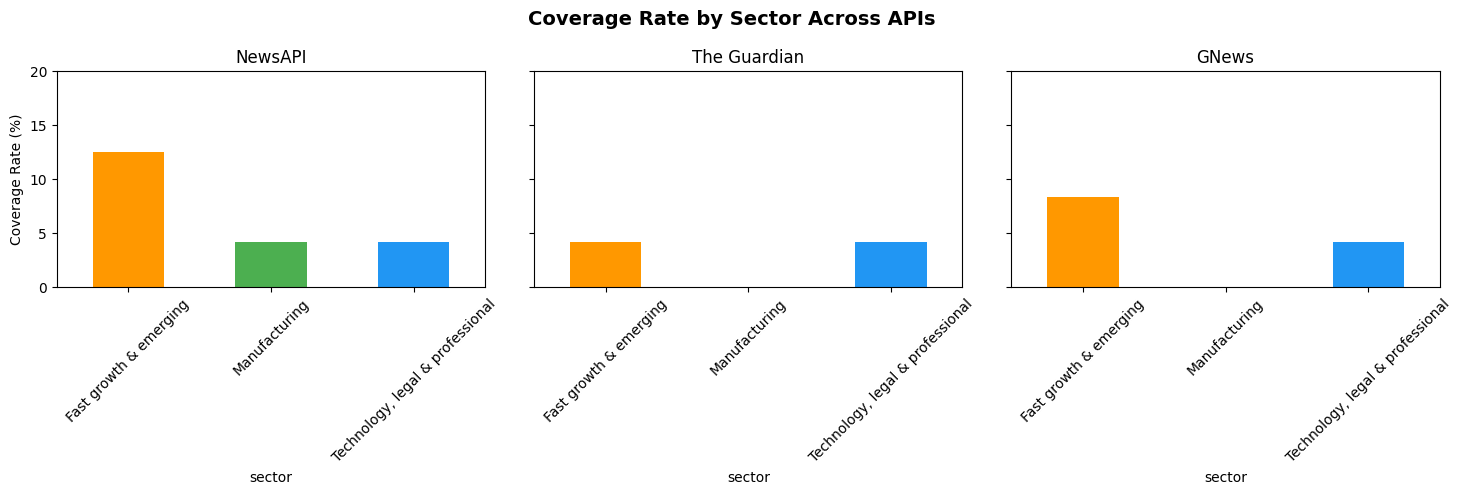

In [38]:
#Sector wise breakdown
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = [
    ("NewsAPI", newsapi_df, "newsapi_has_coverage"),
    ("The Guardian", guardian_df, "guardian_has_coverage"),
    ("GNews", gnews_df, "gnews_has_coverage"),
]

for ax, (api_name, data, col) in zip(axes, datasets):
    sector_rates = data.groupby("sector")[col].mean() * 100
    sector_rates.plot(kind="bar", ax=ax, color=["#FF9800", "#4CAF50", "#2196F3"])
    ax.set_title(api_name)
    ax.set_ylabel("Coverage Rate (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 20)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Coverage Rate by Sector Across APIs", fontsize=14, fontweight="bold")
plt.tight_layout()


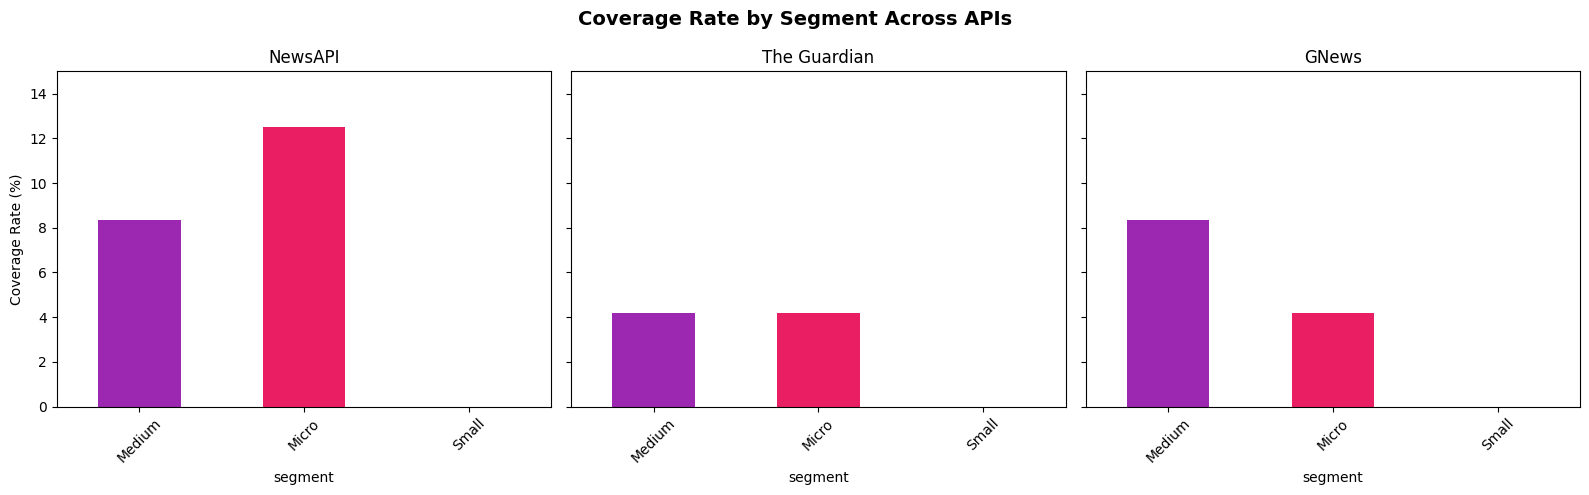

In [39]:
#Segment wise breakdown
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (api_name, data, col) in zip(axes, datasets):
    segment_rates = data.groupby("segment")[col].mean() * 100
    segment_rates.plot(kind="bar", ax=ax, color=["#9C27B0", "#E91E63", "#00BCD4"])
    ax.set_title(api_name)
    ax.set_ylabel("Coverage Rate (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 15)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Coverage Rate by Segment Across APIs", fontsize=14, fontweight="bold")
plt.tight_layout()

---

The below code is just experimental to check of metrics differ across segments and sectors with visualization

I am creating some already exisiting Companies house metrics (which have been created by viktor ) with 1 or 2 extra additions

- since the news layer would'nt carry enough weight for SMEs, the structured metrics become even more important here.

In [40]:
# Parse dates first
df["IncorporationDate"] = pd.to_datetime(df["IncorporationDate"], format="%d/%m/%Y", errors="coerce")

# Metric 1: Company age
df["company_age_years"] = ((pd.Timestamp.now() - df["IncorporationDate"]).dt.days / 365.25).round(1)

# Metric 2: Active debt flag
df["has_outstanding_debt"] = df["Mortgages.NumMortOutstanding"] > 0

# Metric 3: Debt ratio (outstanding / total charges)
df["debt_ratio"] = (
    df["Mortgages.NumMortOutstanding"] / df["Mortgages.NumMortCharges"]
).fillna(0).round(3)

# Metric 4: Is diversified (multiple SIC codes)
df["is_diversified"] = df["SICCode.SicText_2"].notna()

# Metric 5: Has changed name before
df["has_changed_name"] = df["PreviousName_1.CONDATE"].notna()

# Metric 6: Foreign owned
df["is_foreign_owned"] = df["CountryOfOrigin"] != "United Kingdom"

In [41]:
# Summary of metrics

print(f"Total companies: {len(df):,}")
print(f"\nCompany age (years):")
print(f"  Mean: {df['company_age_years'].mean():.1f}")
print(f"  Median: {df['company_age_years'].median():.1f}")
print(f"\nActive debt: {df['has_outstanding_debt'].mean():.1%} of companies")
print(f"\nDebt ratio (among those with any charges):")
charged = df[df["Mortgages.NumMortCharges"] > 0]
print(f"  Mean: {charged['debt_ratio'].mean():.2f}")
print(f"  Median: {charged['debt_ratio'].median():.2f}")
print(f"\nDiversified (multiple SIC codes): {df['is_diversified'].mean():.1%}")
print(f"Has changed name: {df['has_changed_name'].mean():.1%}")
print(f"Foreign owned: {df['is_foreign_owned'].mean():.1%}")

Total companies: 1,372,321

Company age (years):
  Mean: 9.5
  Median: 6.2

Active debt: 6.7% of companies

Debt ratio (among those with any charges):
  Mean: 0.55
  Median: 0.50

Diversified (multiple SIC codes): 30.1%
Has changed name: 10.9%
Foreign owned: 0.0%


In [43]:
#now checking how these metrics differ across segments & sectors

metrics_cols = ["company_age_years", "has_outstanding_debt", "debt_ratio",
                "is_diversified", "has_changed_name", "is_foreign_owned"]

print("Metrics by segment")

segment_summary = df.groupby("segment")[metrics_cols].mean().round(3)
print(segment_summary.to_string())


print("Metrics by sector")

sector_summary = df.groupby("sector")[metrics_cols].mean().round(3)
print(sector_summary.to_string())

Metrics by segment
            company_age_years  has_outstanding_debt  debt_ratio  is_diversified  has_changed_name  is_foreign_owned
segment                                                                                                            
Dormant                11.203                 0.029       0.023           0.296             0.120               0.0
Large                  27.604                 0.484       0.281           0.203             0.360               0.0
Medium                 29.222                 0.634       0.361           0.243             0.268               0.0
Micro                  10.034                 0.031       0.028           0.287             0.109               0.0
No Filings              0.850                 0.005       0.005           0.413             0.028               0.0
Small                  13.527                 0.141       0.111           0.242             0.145               0.0
Subsidiary             21.022                 0.436  

---
I have commented the below block out as markdown, if you wish to see the visulisations, change from markdown -> code block. The output is 2 x 3 graphs showing how metrics differ.

#Visualising the structured metrics 


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Company age distribution by segment
df.boxplot(column="company_age_years", by="segment", ax=axes[0,0])
axes[0,0].set_title("Company Age by Segment")
axes[0,0].set_ylabel("Years")

# Debt ratio by segment
charged = df[df["Mortgages.NumMortCharges"] > 0]
charged.boxplot(column="debt_ratio", by="segment", ax=axes[0,1])
axes[0,1].set_title("Debt Ratio by Segment")

# Active debt rate by sector
df.groupby("sector")["has_outstanding_debt"].mean().plot(kind="bar", ax=axes[0,2])
axes[0,2].set_title("% with Outstanding Debt by Sector")
axes[0,2].tick_params(axis="x", rotation=45)

# Diversification by segment
df.groupby("segment")["is_diversified"].mean().plot(kind="bar", ax=axes[1,0])
axes[1,0].set_title("% Diversified by Segment")

# Name changes by segment
df.groupby("segment")["has_changed_name"].mean().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("% Name Changed by Segment")

# Foreign ownership by sector
df.groupby("sector")["is_foreign_owned"].mean().plot(kind="bar", ax=axes[1,2])
axes[1,2].set_title("% Foreign Owned by Sector")
axes[1,2].tick_params(axis="x", rotation=45)

plt.suptitle("Companies House Structured Metrics Overview", fontsize=14, fontweight="bold")
plt.tight_layout()